### Student performance indicator

#### life cycle of ml project
1. understanding the problem statement
2. data collection
3. data checks to perform
4. Exploratory data analysis
5. Data pre-processing
6. model training
7. choose best model

### 1) Problem Statement

* This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

### 2) Data Collection

* Dataset Source: [https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977)
* The data consists of 8 columns and 1000 rows.


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

### Data checks to perform
1. check the missing values
2. check Duplicates
3. check data type
4. check the number of unique values of each column
5. check statistics of dataset
6. check various categories present in the different categorical column

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


3 # EXPLORING DATA

In [12]:
print("categories in 'gender' column:", end=" ")
print(df['gender'].unique())

print("categories in 'race_ethnicity' column:", end=" ")
print(df['race_ethnicity'].unique())

print("categories in 'parental_level_of_education' column:", end=" ")
print(df['parental_level_of_education'].unique())

print("categories in 'lunch' column:", end=" ")
print(df['lunch'].unique())

print("categories in 'test_preparation_course' column:", end=" ")
print(df['test_preparation_course'].unique())

categories in 'gender' column: <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race_ethnicity' column: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental_level_of_education' column: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch' column: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test_preparation_course' column: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
## define numerical and categoirical columns
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

# print columns
print('we have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('we have {} categorical features : {}'.format(len(categorical_features), categorical_features))

we have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
we have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [14]:
## Adding column for total score and average score
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
writing_full = df[df['writing_score']==100]['average_score'].count()
reading_full = df[df['reading_score']==100]['average_score'].count()
math_full = df[df['math_score']==100]['average_score'].count()

print("Number of students with full marks in writing score:", {writing_full})
print("Number of students with full marks in reading score:", {reading_full})
print("Number of students with full marks in math score:", {math_full})

Number of students with full marks in writing score: {np.int64(14)}
Number of students with full marks in reading score: {np.int64(17)}
Number of students with full marks in math score: {np.int64(7)}


In [16]:
reading_less_20 = df[df['reading_score']<20]['average_score'].count()
writing_less_20 = df[df['writing_score']<20]['average_score'].count()
math_less_20 = df[df['math_score']<20]['average_score'].count()

print("Number of students with reading score less than 20:", {reading_less_20})
print("Number of students with writing score less than 20:", {writing_less_20})
print("Number of students with math score less than 20:", {math_less_20})

Number of students with reading score less than 20: {np.int64(1)}
Number of students with writing score less than 20: {np.int64(3)}
Number of students with math score less than 20: {np.int64(4)}


## 4. Exploring data (visualization)
visualize average score distribution to make some conclusion
1. histogram
2. kernel distribution function(KDE)

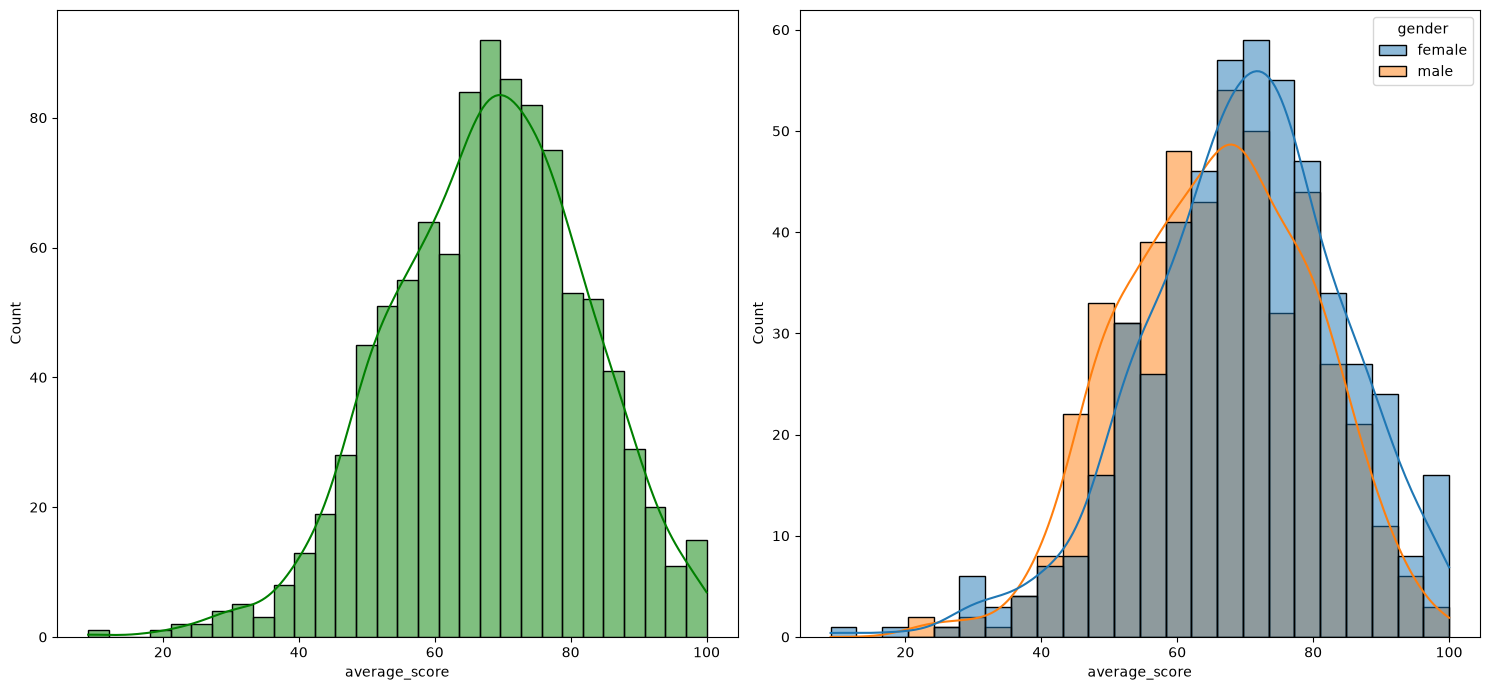

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g', ax=axs[0])
sns.histplot(data=df, x='average_score', kde=True, hue='gender', ax=axs[1])
plt.tight_layout()
plt.show()

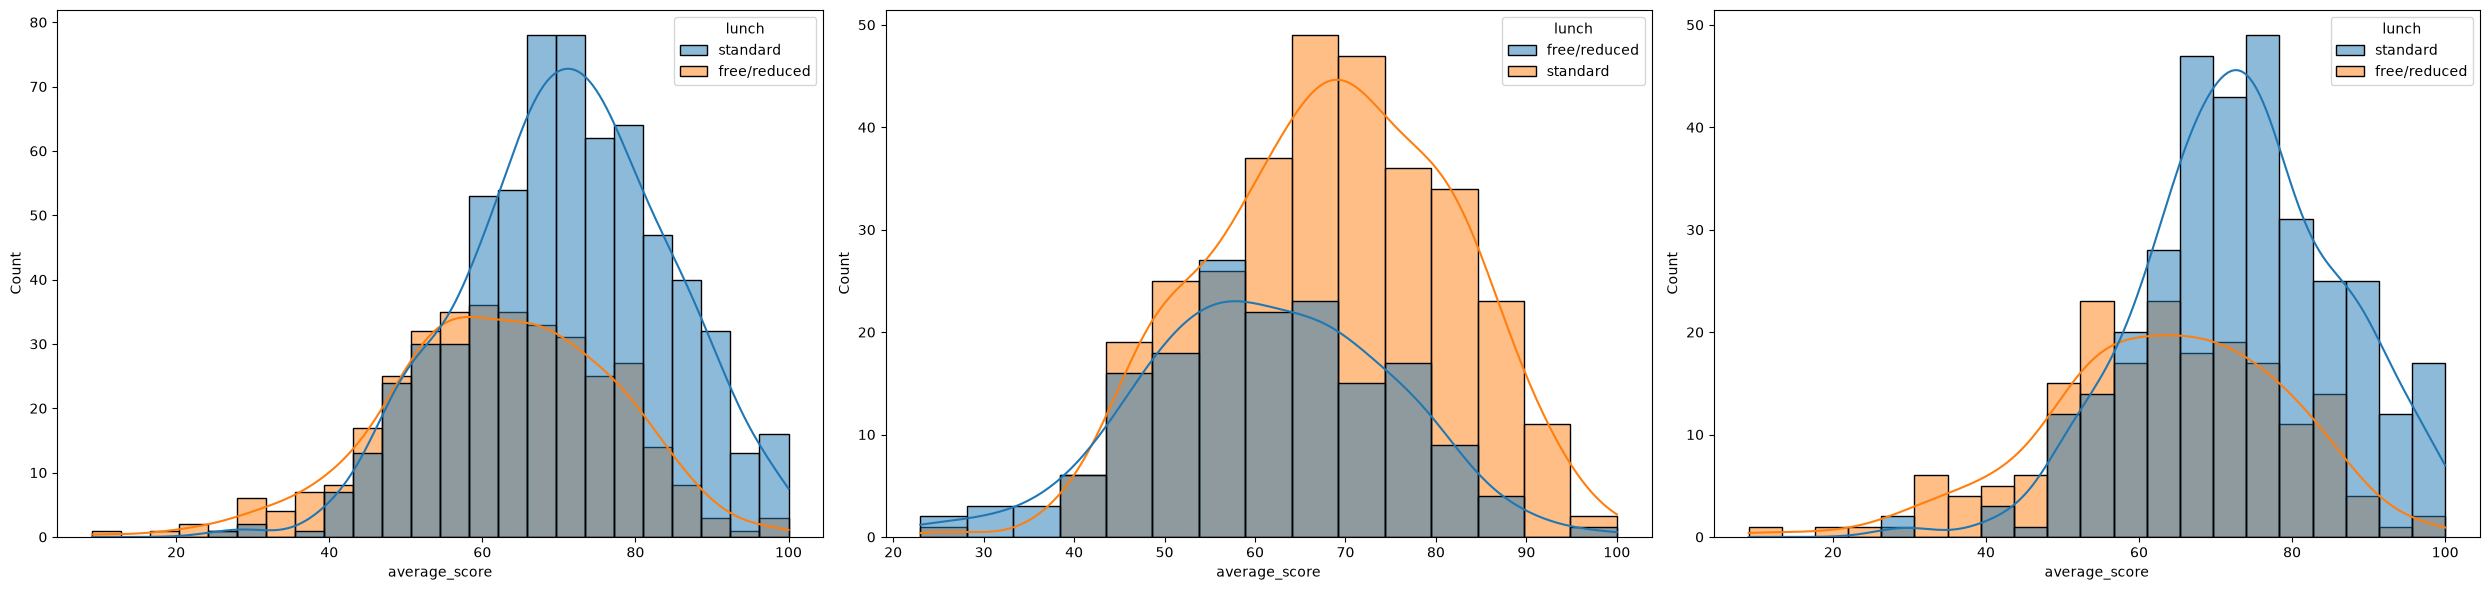

In [18]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='lunch')
plt.tight_layout()
plt.show()

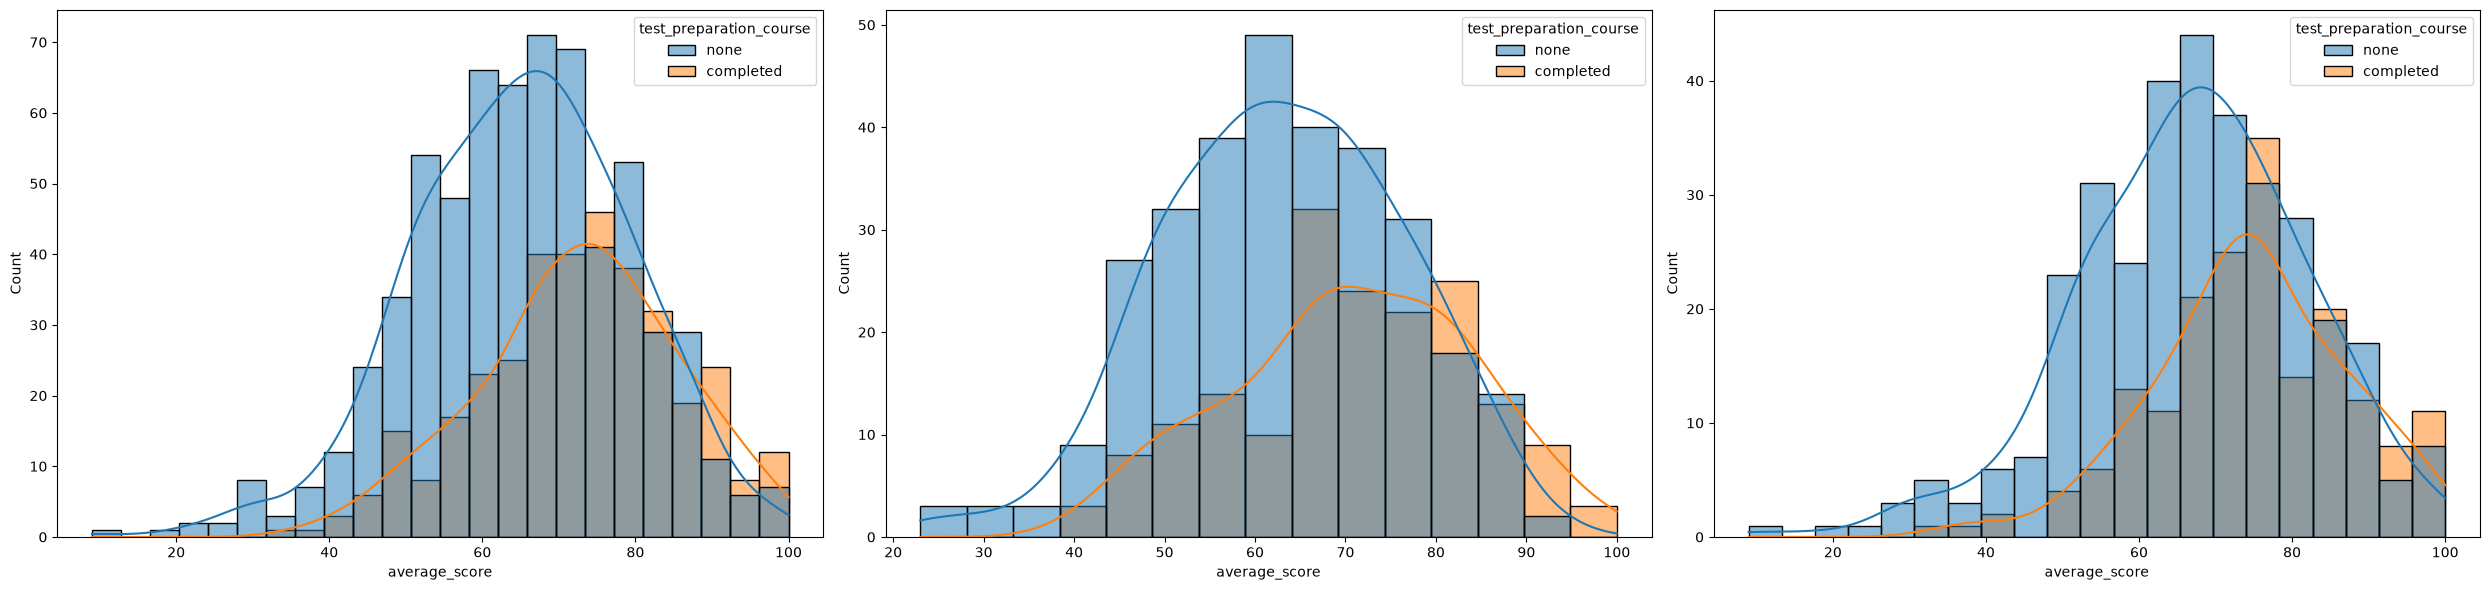

In [19]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='test_preparation_course')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='test_preparation_course')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='test_preparation_course')
plt.tight_layout()
plt.show()

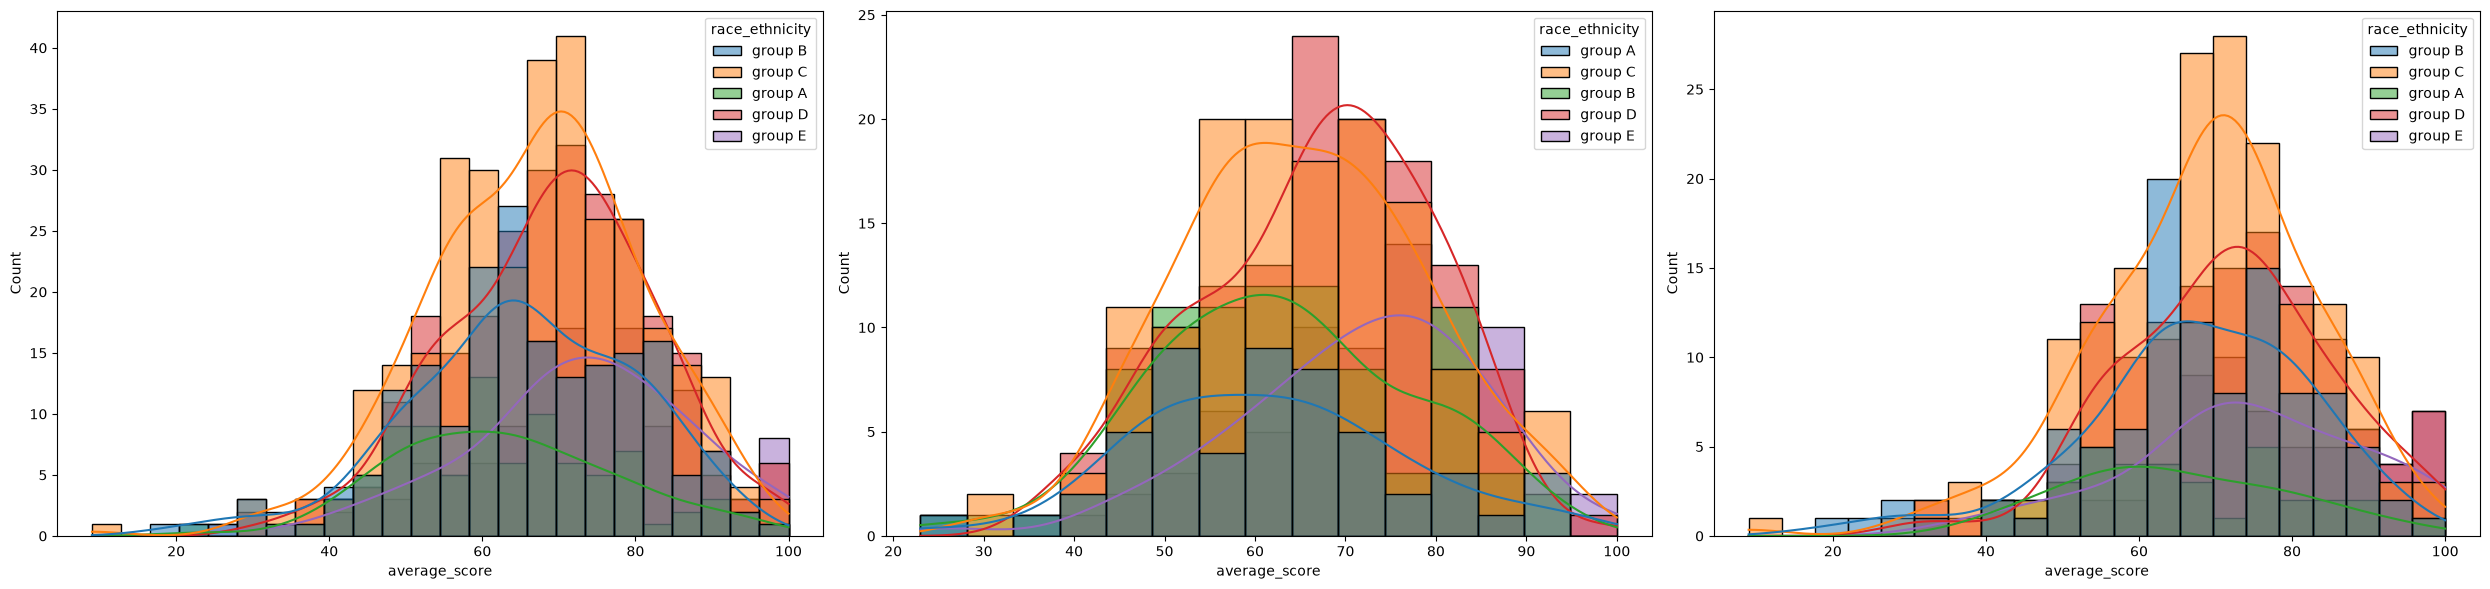

In [21]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='race_ethnicity')
plt.tight_layout()
plt.show()

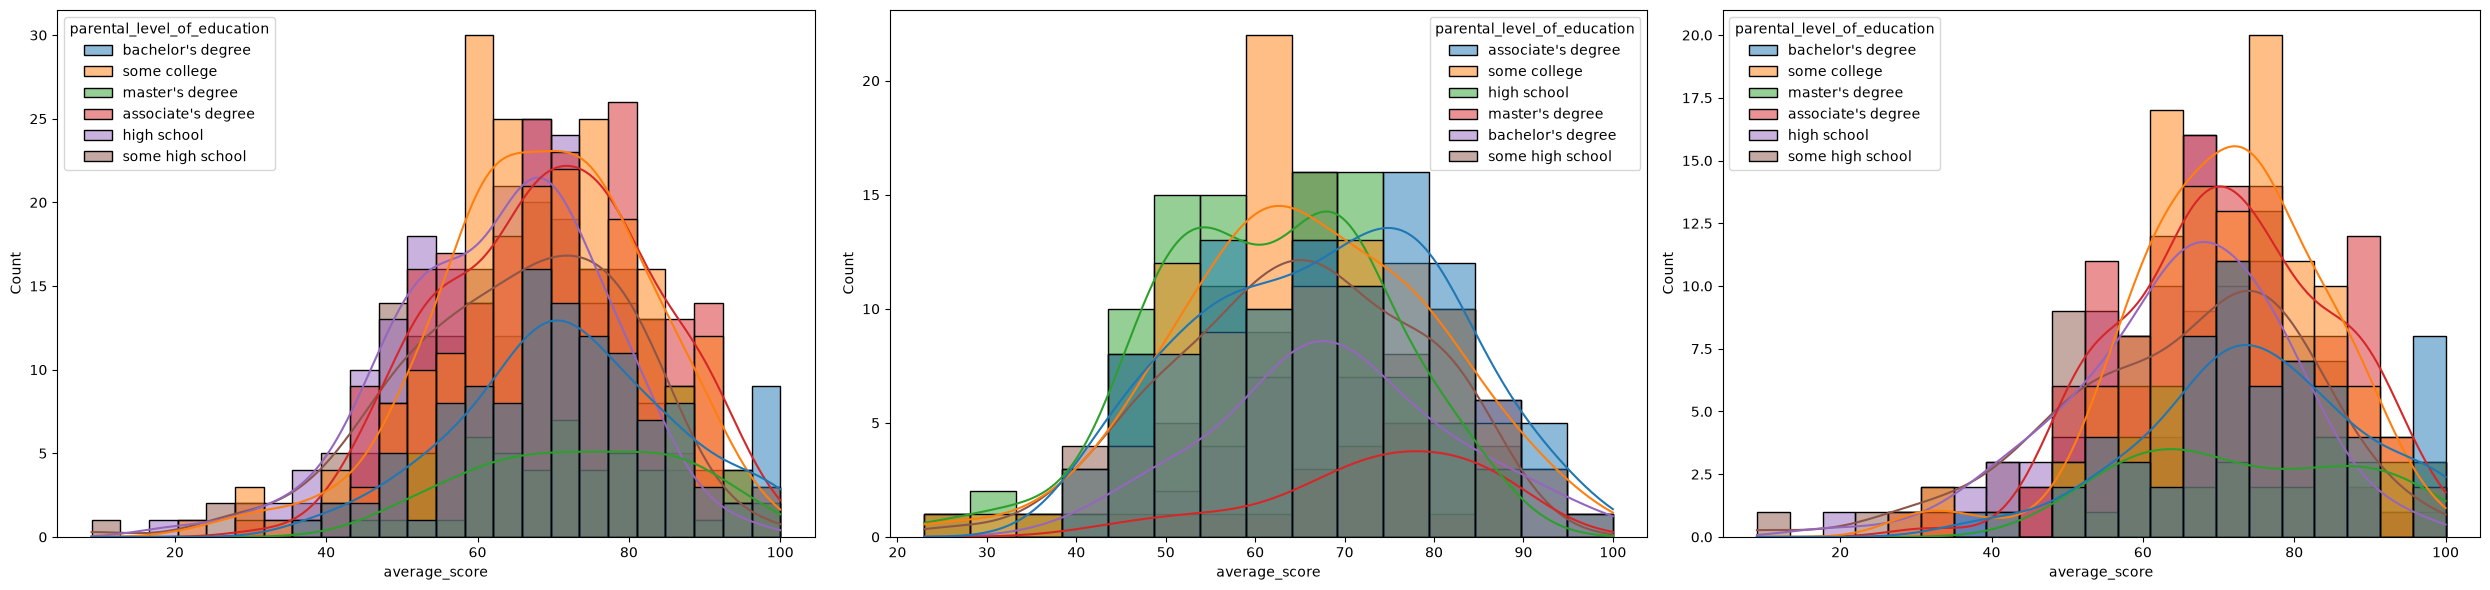

In [22]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='parental_level_of_education')
plt.tight_layout()
plt.show()